In [4]:
import rasterio as rio
from pathlib import Path
from google.colab import drive
drive.mount('/content/drive/')
import sys
sys.path.append('/content/drive/MyDrive/IRP/scripts')
import numpy as np
import DataStack as ds
import matplotlib.pyplot as plt
import glob

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


Load training sets

In [ ]:
regions = ['Russia', 'EastQuantock', 'UKTraining', 'USA', 'Russia2']

region_meta = {'Russia': {'res': 3, 'sigma_px': 30, 'cluster': True},
               'Russia2': {'res': 3, 'sigma_px': 30, 'cluster': False},
               'UKTraining': {'res': 1, 'sigma_px': 10, 'cluster': False},
               'EastQuantock': {'res': 1, 'sigma_px': 10, 'cluster': False},
               'USA': {'res': 1, 'sigma_px': 10, 'cluster': False},
               'Russia3': {'res': 3, 'sigma_px': 30, 'cluster': False}}

for region in regions:
  print(f'Tiling {region}...')
  DEM_PATH = f'/content/drive/MyDrive/IRP/Data/{region}/DEM.tif'
  LABEL_PATH = f'/content/drive/MyDrive/IRP/Data/{region}/Labels.shp'

  dem = ds.DataSource.from_tiff_utm(DEM_PATH, target_res=region_meta[region]['res'])
  labels = ds.ShapeLabels(LABEL_PATH)
  stack = ds.DataStack(dem, label_shp=labels, sigma_px=region_meta[region]['sigma_px'])
  stack.tile_and_export(512, f'/content/drive/MyDrive/IRP/TilesJittered/{region}',
                        negative=0.1,
                        jitter_margin_frac=0.20,
                        cluster = region_meta[region]['cluster'],
                        edge_tolerance = 0.1)

  del labels
  del dem
  del stack


Tiling Russia...
Found 346 positive tiles
Sampling 13 negative tiles
Done. 130 positive, 13 negative.
Tiling EastQuantock...
Found 8 positive tiles
Sampling 1 negative tiles
Done. 8 positive, 1 negative.
Tiling UKTraining...
Found 10 positive tiles
Sampling 1 negative tiles
Done. 10 positive, 1 negative.
Tiling USA...
Found 80 positive tiles
Sampling 5 negative tiles
Done. 53 positive, 5 negative.
Tiling Russia2...
Found 28 positive tiles
Sampling 2 negative tiles
Done. 20 positive, 2 negative.


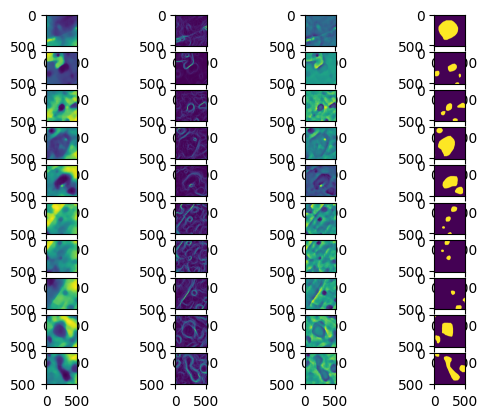

In [13]:
paths = glob.glob('/content/drive/MyDrive/IRP/TilesJittered/Russia/*.npz')[:10]

fig, axes = plt.subplots(10, 4)

for i, path in enumerate(paths):
  d = np.load(path)
  axes[i, 0].imshow(d['image'][0])
  axes[i, 1].imshow(d['image'][1])
  axes[i, 2].imshow(d['image'][3])
  axes[i, 3].imshow(d['labels'])
